In [7]:
import numpy as np
from sympy import sin, cos 
import sympy as sp
import scipy as scp
import pandas as pd
from cmath import *
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scienceplots
plt.style.context(['science'])
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "Times New Roman"
import pickle
import timeit
import glob # need to merge arrays
import os # need to make directory
from scipy.interpolate import interp1d
from scipy.integrate import quad

import ternary

print("Version", ternary.__version__)

t0 = timeit.default_timer()

Version 1.0.8


### Haar measure contrast

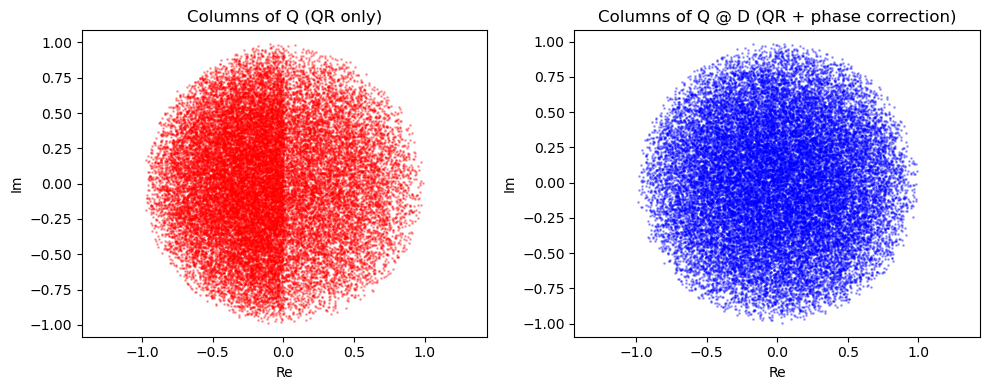

In [55]:
def random_unitary_Q():
    Z = np.random.randn(3,3) + 1j*np.random.randn(3,3)
    Q, R = np.linalg.qr(Z)
    return Q

def random_unitary_QD():
    Z = np.random.randn(3,3) + 1j*np.random.randn(3,3)
    Q, R = np.linalg.qr(Z)
    D = np.diag(np.exp(1j*np.angle(np.diag(R))))
    return Q @ D

n_samples = 10000
cols_Q = []
cols_QD = []

for _ in range(n_samples):
    Q = random_unitary_Q()
    QD = random_unitary_QD()
    cols_Q.append(Q[:,0])    # first column
    cols_QD.append(QD[:,0])

cols_Q = np.array(cols_Q).flatten()
cols_QD = np.array(cols_QD).flatten()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(cols_Q.real, cols_Q.imag, s=1, color="red", alpha=0.3)
plt.title("Columns of Q (QR only)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.axis("equal")

plt.subplot(1,2,2)
plt.scatter(cols_QD.real, cols_QD.imag, s=1, color="blue", alpha=0.3)
plt.title("Columns of Q @ D (QR + phase correction)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.axis("equal")

plt.tight_layout()
plt.show()

left directional preference when only Q considered

## LIV Hamiltonian class

In [8]:
import numpy as np
from scipy.linalg import expm

class NeutrinoHamiltonian:
    """
    Neutrino Hamiltonian with optional new-physics operators.

    Parameters
    ----------
    theta12, theta13, theta23 : float
        PMNS mixing angles in radians.
    delta_cp : float
        CP-violating phase in radians.
    dm21, dm31 : float
        Mass-squared differences (eV^2).
    E : float
        Neutrino energy (eV).
    n_terms : int
        Number of new-physics operators (default 2).
    seed : int, optional
        Random seed for reproducibility.
    O_n_list : list of 3x3 numpy arrays, optional
        List of diagonal operator matrices. Length must equal n_terms if given.
    Lambda_n_list : list of floats, optional
        List of new-physics energy scales (same length as n_terms if given).
    U_n_list : list of 3x3 unitary matrices, optional
        If not provided, random unitaries will be generated.
    """
    def __init__(self, theta12, theta13, theta23, delta_cp,
                 dm21, dm31, #E,
                 n_terms=2,
                 seed=None,
                 O_n_list=None,
                 Lambda_n_list=None,
                 U_n_list=None):
        
        if seed is not None:
            np.random.seed(seed)

        # store parameters
        self.theta12 = theta12
        self.theta13 = theta13
        self.theta23 = theta23
        self.delta_cp = delta_cp
        self.dm21 = dm21
        self.dm31 = dm31
#         self.E = E
        self.n_terms = n_terms

        # PMNS mixing matrix
        self.U_pmns = self._pmns_matrix()

        # ---- handle optional new-physics inputs ----
        # O_n_list: diagonal 3x3 matrices
        if O_n_list is None:
            self.O_n_list = [self._random_diag() for _ in range(n_terms)]
        else:
            if len(O_n_list) != n_terms:
                raise ValueError("O_n_list length must match n_terms")
            self.O_n_list = O_n_list

        # U_n_list: unitary matrices
        if U_n_list is None:
            self.U_n_list = [self._random_unitary() for _ in range(n_terms)]
        else:
            if len(U_n_list) != n_terms:
                raise ValueError("U_n_list length must match n_terms")
            self.U_n_list = U_n_list

        # Lambda_n_list: energy scales
        if Lambda_n_list is None:
            self.Lambda_n_list = [1e-2 * (i + 1) for i in range(n_terms)]
        else:
            if len(Lambda_n_list) != n_terms:
                raise ValueError("Lambda_n_list length must match n_terms")
            self.Lambda_n_list = Lambda_n_list

        # precompute Hamiltonian and effective mixing
        self.H = self._total_hamiltonian(E)
        self.V_eff = self._effective_mixing_matrix()

    # ---------- helper methods ----------

    def _pmns_matrix(self):
        s12, s13, s23 = np.sin(self.theta12), np.sin(self.theta13), np.sin(self.theta23)
        c12, c13, c23 = np.cos(self.theta12), np.cos(self.theta13), np.cos(self.theta23)
        δ = self.delta_cp
        return np.array([
            [c12*c13, s12*c13, s13*np.exp(-1j*δ)],
            [-s12*c23 - c12*s23*s13*np.exp(1j*δ),
             c12*c23 - s12*s23*s13*np.exp(1j*δ),
             s23*c13],
            [s12*s23 - c12*c23*s13*np.exp(1j*δ),
             -c12*s23 - s12*c23*s13*np.exp(1j*δ),
             c23*c13]
        ], dtype=complex)

    def _random_diag(self):
        """Random diagonal 3×3 matrix with entries in [-1,1]."""
        return np.diag(np.random.uniform(-1, 1, 3))

    def _random_unitary(self):
        """Generate a random 3×3 unitary matrix using QR decomposition + phase fix."""
        Z = np.random.randn(3,3) + 1j*np.random.randn(3,3)
        Q, R = np.linalg.qr(Z)
        D = np.diag(np.exp(1j*np.angle(np.diag(R))))
        return Q @ D
    
#    ### wanted to exactly reproduce fig 8 from Mauricio 2503.15468 
#     def _dcn_LIV_hamiltonian(self, E):
#         H_dcn_LIV = np.zeros((3,3), dtype=complex)
        

    def _total_hamiltonian(self, E):
        """Vacuum + new-physics Hamiltonian in flavor basis."""
        H0 = self.U_pmns @ np.diag([0, self.dm21/(2*E), self.dm31/(2*E)]) @ self.U_pmns.conj().T
        H_new = np.zeros((3,3), dtype=complex)
        for n in range(self.n_terms):
            H_new += (E / self.Lambda_n_list[n])**n * self.O_n_list[n] * (
                self.U_n_list[n] @ np.diag(np.random.rand(3)) @ self.U_n_list[n].conj().T
            )
        return H0 + H_new

    def _show_distinct_hamiltonian(self, E):
        """Vacuum + new-physics Hamiltonian in flavor basis."""
        H0 = self.U_pmns @ np.diag([0, self.dm21/(2*E), self.dm31/(2*E)]) @ self.U_pmns.conj().T
        H_new = np.zeros((3,3), dtype=complex)
        for n in range(self.n_terms):
            H_new += (E / self.Lambda_n_list[n])**n * self.O_n_list[n] * (
                self.U_n_list[n] @ np.diag(np.random.rand(3)) @ self.U_n_list[n].conj().T
            )
            
        return H0, H_new
    
    def print_distinct_hamiltonian(self, E):
        H0, H_new = self._show_distinct_hamiltonian(E)
        print("H0=\n",H0)
        print("H_new=\n",H_new)
        return None
    
    def _effective_mixing_matrix(self):
        """Diagonalize total Hamiltonian to get effective mixing matrix."""
        _, evecs = np.linalg.eigh(self.H)
        return evecs

    def show_effective_mixing_matrix(self):
        """Diagonalize total Hamiltonian to get effective mixing matrix."""
        H0, H_new = self._show_distinct_hamiltonian(E)

        _, evecs_0 = np.linalg.eigh(self.H0)
        print("PMNS with LIV=0:\n",evecs0)

        _, evecs_LIV = np.linalg.eigh(self.H_new)
        print("PMNS with LIV=0:\n",H_new)
        
        return None


    def flavor_ratio(self, phi0, Eany):
        """
        Averaged flavor ratio at a single energy E (defaults to self.E).
        phi0 : array-like
            Initial flavor flux [phi_e, phi_mu, phi_tau].
        E : float, optional
            Energy in eV.  Uses self.E if not supplied.
        """
        if Eany is None:
            Eany = self.E
        Htot = self._total_hamiltonian(Eany)
        _, evecs = np.linalg.eigh(Htot)
        V = evecs

        Pbar = np.zeros((3,3))
        for α in range(3):
            for β in range(3):
                Pbar[α, β] = np.sum(np.abs(V[α, :])**2 * np.abs(V[β, :])**2)
        return Pbar @ phi0
    
    def flavor_ratio_integrated(self, phi0, E_bins, weights=None):
        """
        Integrate the flavor ratio over an array of energies.

        Parameters
        ----------
        phi0 : array-like
            Initial flavor flux [phi_e, phi_mu, phi_tau].
        E_bins : array-like
            1-D array of energies (eV) to integrate over.
        weights : array-like, optional
            Weights for each energy (e.g. flux spectrum). 
            If None, uses equal weighting.

        Returns
        -------
        np.ndarray
            Integrated/weighted average flavor ratio [phi_e, phi_mu, phi_tau].
        """
        E_bins = np.asarray(E_bins)
        if weights is None:
            weights = np.ones_like(E_bins)
        weights = np.asarray(weights)

        ratios = np.array([self.flavor_ratio(phi0, E) for E in E_bins])
        # weighted average across energies
        return np.average(ratios, axis=0, weights=weights)

In [1115]:
nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31, 
                         n_terms=len(O_custom),
                         O_n_list=[0,3.6e-26 * 1e9],
                         Lambda_n_list=Lambda_custom,
                         seed=19)

for Ex in [6,9,12,15,18,21,24]:
    E = 10**Ex
    print(Ex, nu.flavor_ratio([1,2,0], E))

nu.print_distinct_hamiltonian(1e18)

6 [1.00456441 1.033905   0.96153059]
9 [1.00456441 1.033905   0.96153059]
12 [1.00507117 1.03364687 0.96128196]
15 [0.83548105 1.33358905 0.8309299 ]
18 [0.83576553 1.33317947 0.831055  ]
21 [0.83576553 1.33317946 0.831055  ]
24 [0.83576553 1.33317946 0.831055  ]
H0=
 [[3.90554376e-23+0.j 1.49102209e-22+0.j 1.09089022e-22+0.j]
 [1.49102209e-22+0.j 7.04180015e-22+0.j 6.02524334e-22+0.j]
 [1.09089022e-22+0.j 6.02524334e-22+0.j 5.61214548e-22+0.j]]
H_new=
 [[ 8.06864236e-13-2.03593641e-29j  2.95579976e-14+1.33974040e-13j
  -9.79824549e-14+1.76209707e-13j]
 [ 2.95579976e-14-1.33974040e-13j  4.67221280e-13-1.57497595e-29j
   3.45153355e-14-7.91748620e-14j]
 [-9.79824549e-14-1.76209707e-13j  3.45153355e-14+7.91748620e-14j
   7.48219585e-13+6.91554704e-30j]]


In [1103]:
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 0, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
Lambda_custom = [35*1e12, 35*1e12]

nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31,
                         n_terms=len(O_custom),
                         O_n_list=[
                             1.e-30 * 1e9,
                                   1.e-35 * 1e9
                         ],
                         Lambda_n_list=Lambda_custom,
                         seed=102)

phi0 = np.array([1, 2, 0])
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e16))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e17))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e18))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e19))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e20))
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e21))

# phi0 = np.array([1.5, 1.5, 0])
E_bins = np.logspace(8, 10, 50)  # 50 energies from 1e8 to 1e10 eV

phi_beta_avg = nu.flavor_ratio_integrated(phi0, E_bins)
print("Integrated flavor ratio:", phi_beta_avg)

nu.print_distinct_hamiltonian(1e18)
# # Energy bins from 1e8 to 1e15 eV (log-spaced)
# E_bins = np.logspace(8, 15, 20)
# phi_beta_avg = nu.flavor_ratio_integrated(phi0, E_bins)
# print("Averaged flavor ratio over energy bins:", phi_beta_avg)

Flavor ratio: [1.02113106 1.02498623 0.95388271]
Flavor ratio: [0.94709746 1.08801729 0.96488525]
Flavor ratio: [1.4017454  1.39523453 0.20302007]
Flavor ratio: [1.41725397 1.41614757 0.16659845]
Flavor ratio: [1.41358776 1.40500273 0.18140951]
Flavor ratio: [1.41463071 1.40829035 0.17707894]
Integrated flavor ratio: [1.0045644  1.033905   0.96153059]
H0=
 [[3.90554376e-23+0.j 1.49102209e-22+0.j 1.09089022e-22+0.j]
 [1.49102209e-22+0.j 7.04180015e-22+0.j 6.02524334e-22+0.j]
 [1.09089022e-22+0.j 6.02524334e-22+0.j 5.61214548e-22+0.j]]
H_new=
 [[ 1.10539604e-21+2.63768785e-38j  1.21413655e-23+2.93524996e-23j
  -4.21096483e-23-1.35351351e-23j]
 [ 1.21413655e-23-2.93524996e-23j  9.30731509e-22-5.58984365e-38j
   1.93659074e-23+7.08346283e-23j]
 [-4.21096483e-23+1.35351351e-23j  1.93659074e-23-7.08346283e-23j
   9.65781732e-22-1.46221875e-38j]]


In [1105]:
nu.print_distinct_hamiltonian(4e18), nu.print_distinct_hamiltonian(6e18)

H0=
 [[9.76385939e-24+0.j 3.72755523e-23+0.j 2.72722556e-23+0.j]
 [3.72755523e-23+0.j 1.76045004e-22+0.j 1.50631084e-22+0.j]
 [2.72722556e-23+0.j 1.50631084e-22+0.j 1.40303637e-22+0.j]]
H_new=
 [[ 1.08423747e-21+1.25476623e-38j -1.17435217e-22+1.64142818e-22j
   1.27814106e-22+4.78573067e-23j]
 [-1.17435217e-22-1.64142818e-22j  1.03439253e-21-9.50402952e-39j
   4.82041467e-23+1.98166915e-22j]
 [ 1.27814106e-22-4.78573067e-23j  4.82041467e-23-1.98166915e-22j
   1.60950193e-21-2.77892411e-40j]]
H0=
 [[6.50923959e-24+0.j 2.48503682e-23+0.j 1.81815037e-23+0.j]
 [2.48503682e-23+0.j 1.17363336e-22+0.j 1.00420722e-22+0.j]
 [1.81815037e-23+0.j 1.00420722e-22+0.j 9.35357579e-23+0.j]]
H_new=
 [[ 1.63419542e-21-2.05930846e-39j -1.87977600e-23+9.51461611e-23j
  -2.35753294e-22-1.10818028e-22j]
 [-1.87977600e-23-9.51461611e-23j  1.61534200e-21+1.55801500e-38j
  -6.21778190e-23-9.32552824e-23j]
 [-2.35753294e-22+1.10818028e-22j -6.21778190e-23+9.32552824e-23j
   7.98834521e-22+3.26422439e-39j]]


(None, None)

Flavor ratio: [1.41770454 1.41370642 0.16858904]


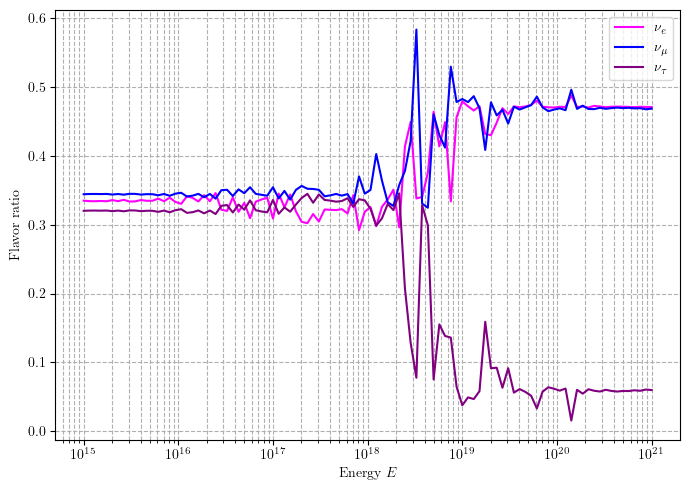

In [1113]:
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 0, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
Lambda_custom = [35*1e12, 35*1e12]

nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31,
                         n_terms=len(O_custom),
                         O_n_list=[
                             1.e-30 * 1e9,
                             2.e-35 * 1e9
                         ],
                         Lambda_n_list=Lambda_custom,
                         seed=102
                        )

phi0 = np.array([1, 2, 0])
print("Flavor ratio:", nu.flavor_ratio(phi0, 10e19))

# Energy range
enrange = np.logspace(15, 21, 100)
# enrange = [10**x for x in np.linspace(18, 19, 10)]
# enrange = np.logspace(18, 19, 100)

# Evaluate flavor ratios
fractions = np.array([nu.flavor_ratio(phi0, e)/np.sum(phi0) for e in enrange])
frace   = fractions[:, 0]
fracmu  = fractions[:, 1]
fractau = fractions[:, 2]

# Plot
plt.figure(figsize=(7,5))
plt.plot(enrange, frace,   label=r'$\nu_e$', color='magenta')
plt.plot(enrange, fracmu,  label=r'$\nu_\mu$', color='blue')
plt.plot(enrange, fractau, label=r'$\nu_\tau$', color='purple')

plt.xscale('log')
plt.xlabel(r'Energy $E$')
plt.ylabel('Flavor ratio')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [1078]:
nu.U_pmns

array([[ 0.82327921+0.j,  0.54796108+0.j,  0.14815532+0.j],
       [-0.45949173+0.j,  0.49008295+0.j,  0.74073345+0.j],
       [ 0.33328471+0.j, -0.6779066 +0.j,  0.65525869+0.j]])

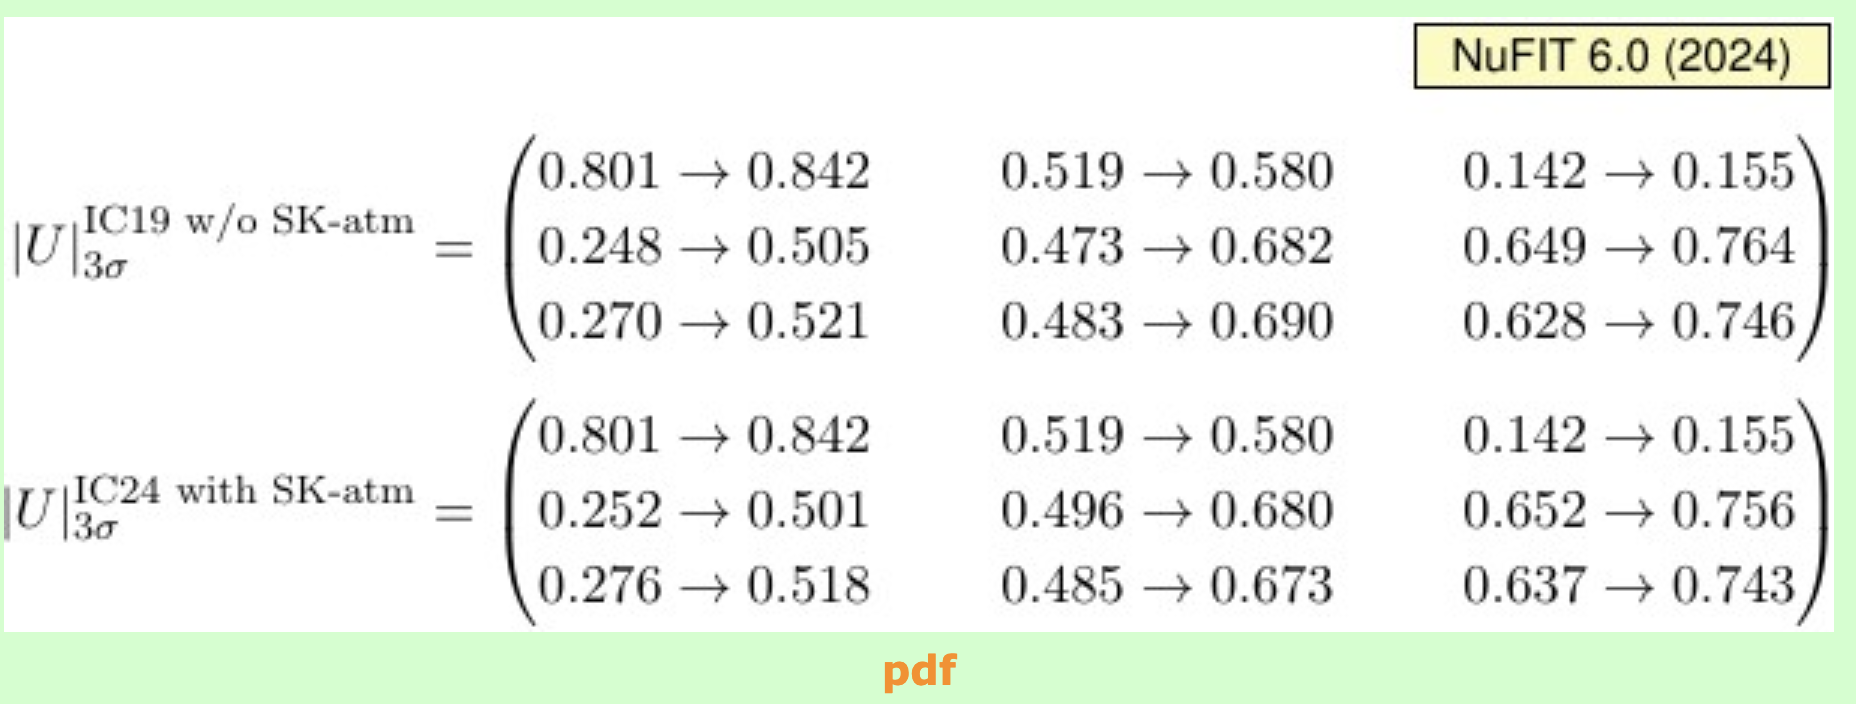

In [1147]:
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 0, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
Lambda_custom = [35*1e12, 35*1e12]

energy_size = 100
nsize = 500

frace_max = []
fracmu_max = []
fractau_max = []

frace_min = []
fracmu_min = []
fractau_min = []

frace_avg = np.zeros(energy_size)
fracmu_avg = np.zeros(energy_size)
fractau_avg = np.zeros(energy_size)

frac_tst = np.ones(energy_size)*1/3

for t in range(nsize):
    pick = np.random.seed(np.random.seed(t))
    
    nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                             dm21, dm31,
                             n_terms=len(O_custom),
                             O_n_list=[
                                 1.e-30 * 1e9,
                                 2.e-35 * 1e9
                             ],
                             Lambda_n_list=Lambda_custom,
                             seed=pick
                            )

    phi0 = np.array([1, 2, 0])
    # print("Flavor ratio:", nu.flavor_ratio(phi0, 10e19))

    # Energy range
    enrange = np.logspace(15, 21, energy_size)

    # Evaluate flavor ratios
    fractions = np.array([nu.flavor_ratio(phi0, e)/np.sum(phi0) for e in enrange])
    frace   = fractions[:, 0]
    fracmu  = fractions[:, 1]
    fractau = fractions[:, 2]
    
    frace_avg += frace
    fracmu_avg += fracmu
    fractau_avg += fractau
    
    ### max
    if t==0:
        frace_max_tst = frace
        fracmu_max_tst = fracmu
        fractau_max_tst = fractau

    frace_max_tst = np.maximum(frace, frace_max_tst)
    fracmu_max_tst = np.maximum(fracmu, fracmu_max_tst)
    fractau_max_tst = np.maximum(fractau, fractau_max_tst)

    frace_max = frace_max_tst
    fracmu_max = fracmu_max_tst
    fractau_max = fractau_max_tst

    ### min
    if t==0:
        frace_min_tst = frace
        fracmu_min_tst = fracmu
        fractau_min_tst = fractau

    frace_min_tst = np.minimum(frace, frace_min_tst)
    fracmu_min_tst = np.minimum(fracmu, fracmu_min_tst)
    fractau_min_tst = np.minimum(fractau, fractau_min_tst)

    frace_min = frace_min_tst
    fracmu_min = fracmu_min_tst
    fractau_min = fractau_min_tst
    
frace_avg = (frace_avg)/nsize
fracmu_avg = (fracmu_avg)/nsize
fractau_avg = (fractau_avg)/nsize

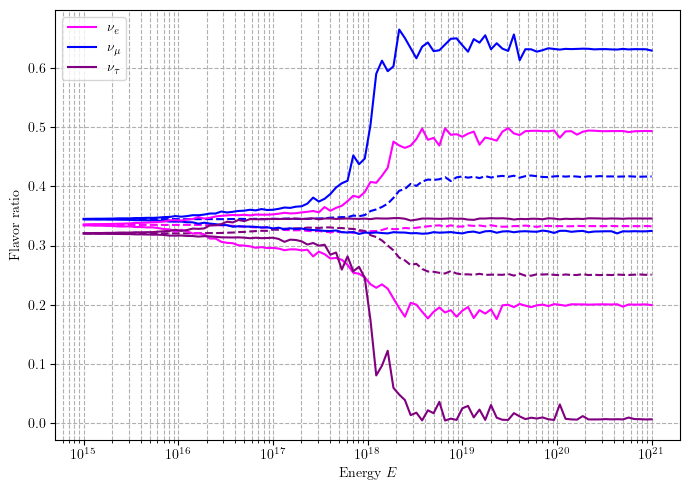

In [1148]:
# Plot
plt.figure(figsize=(7,5))
plt.plot(enrange, frace_avg, color='magenta', linestyle='dashed')
plt.plot(enrange, fracmu_avg, color='blue', linestyle='dashed')
plt.plot(enrange, fractau_avg, color='purple', linestyle='dashed')

plt.plot(enrange, frace_min,   color='magenta', linestyle='solid')
plt.plot(enrange, fracmu_min,  color='blue', linestyle='solid')
plt.plot(enrange, fractau_min, color='purple', linestyle='solid')

plt.plot(enrange, frace_max,   label=r'$\nu_e$', color='magenta', linestyle='solid')
plt.plot(enrange, fracmu_max,  label=r'$\nu_\mu$', color='blue', linestyle='solid')
plt.plot(enrange, fractau_max, label=r'$\nu_\tau$', color='purple', linestyle='solid')

plt.xscale('log')
plt.xlabel(r'Energy $E$')
plt.ylabel('Flavor ratio')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [1139]:
# 500
print(fractau_max,'\n', fractau_avg,'\n', fractau_min)

[0.32095748 0.32264622 0.33314435 0.34488477 0.34500015 0.34535136
 0.34344578 0.3455216  0.34637146 0.34620324] 
 [0.32051173 0.32052947 0.3209794  0.32690706 0.33012226 0.28324995
 0.25104641 0.24970041 0.25099668 0.25103451] 
 [0.32012065 0.31853768 0.31450688 0.31285798 0.28687391 0.02038944
 0.01938431 0.01967337 0.01823526 0.0183482 ]


In [1135]:
print(fractau_max,'\n', fractau_avg,'\n', fractau_min)

[0.32074224 0.32464346 0.34492538 0.33638077 0.34040537 0.34061853] 
 [0.32050535 0.32089617 0.33104603 0.25853187 0.25171332 0.25141621] 
 [0.32022155 0.31741891 0.31063375 0.08164541 0.08789653 0.09186004]


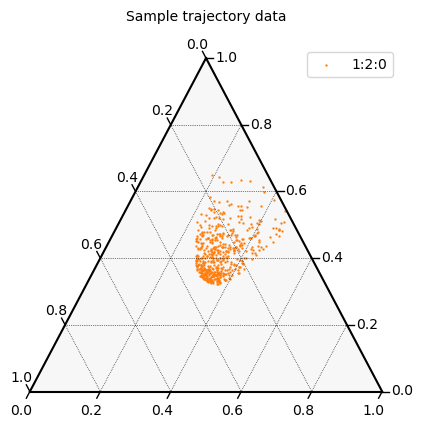

In [186]:
points = []
for t in range(500):
    pick = np.random.seed(np.random.seed(t))
    O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 1, 1])]
    Lambda_custom = [35*1e12, 35*1e12]

    Enu = 1e18
    nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                             dm21, dm31, Enu,
                             n_terms=len(O_custom),
#                                  O_n_list=O_custom,
#                                  Lambda_n_list=Lambda_custom,
                             seed=pick)

    phi_beta = nu.flavor_ratio_integrated([1,2,0], E_bins)
    # normalize so a+b+c = 1 for ternary plot
    phi_beta = phi_beta / phi_beta.sum()
    points.append(phi_beta)

# print(points)

figure, tax = ternary.figure(scale=1.0)
figure.set_size_inches(5, 5)
tax.boundary()
tax.gridlines(multiple=0.2, color="black")
tax.set_title("Sample trajectory data\n", fontsize=10)
tax.scatter(points, s=2, linewidth=.2, label="1:2:0")
tax.ticks(axis='lbr', multiple=0.2, linewidth=1, tick_formats="%.1f", offset=0.02)

tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
tax.legend()
tax.show()

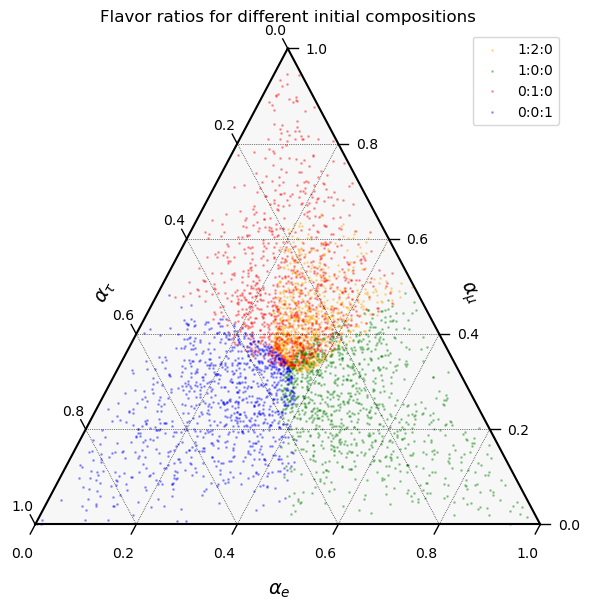

In [194]:
ratios = [
    (np.array([1,2,0]), "1:2:0", "orange"),
    (np.array([1,0,0]), "1:0:0", "green"),
    (np.array([0,1,0]), "0:1:0", "red"),
    (np.array([0,0,1]), "0:0:1", "blue"),
]

# collect points for each initial ratio
all_points = {}
for phi0, label, color in ratios:
    pts = []
    for t in range(1000):   # 200 random Hamiltonians per ratio
        pick = np.random.seed(np.random.seed(t))
        O_custom = [np.diag([0., 0., 0.]), 3.6e-26 * 1e9 * np.diag([1, 2, 3])]
        Lambda_custom = [35*1e12, 35*1e12]

        Enu = 1e18
        nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                                 dm21, dm31, Enu,
                                 n_terms=len(O_custom),
#                                  O_n_list=O_custom,
#                                  Lambda_n_list=Lambda_custom,
                                 seed=pick)

        phi_beta = nu.flavor_ratio_integrated(phi0, E_bins)
        # normalize so a+b+c = 1 for ternary plot
        phi_beta = phi_beta / phi_beta.sum()
        pts.append(tuple(phi_beta))
    all_points[label] = (pts, color)

# --- plotting ---
figure, tax = ternary.figure(scale=1.0)
figure.set_size_inches(6, 6)

tax.boundary()
tax.gridlines(multiple=0.2, color="black")
tax.set_title("Flavor ratios for different initial compositions", fontsize=12)
tax.left_axis_label(r"$\alpha_{\tau}$", fontsize=14, offset=0.12)
tax.right_axis_label(r"$\alpha_{\mu}$", fontsize=14, offset=0.12)
tax.bottom_axis_label(r"$\alpha_{e}$", fontsize=14, offset=0.06)

for label, (pts, color) in all_points.items():
    tax.scatter(pts, s=1, color=color, label=label, alpha=0.3)

tax.ticks(axis='lbr', multiple=0.2, linewidth=1,
          tick_formats="%.1f", offset=0.02)

# tax.legend(
#     title="Initial Ratios",
#     loc="upper right",       # you can choose other positions
#     frameon=False,
#     fontsize=10
# )

tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
tax.legend()
plt.tight_layout()
plt.savefig('scan_LIV.png',dpi=400)
tax.show()

In [218]:
365*24*3600/1e7

3.1536

In [222]:
1e9 * 2.44*3/(1e6 * 16 * 365*24*3600)

1.4507229832572299e-05

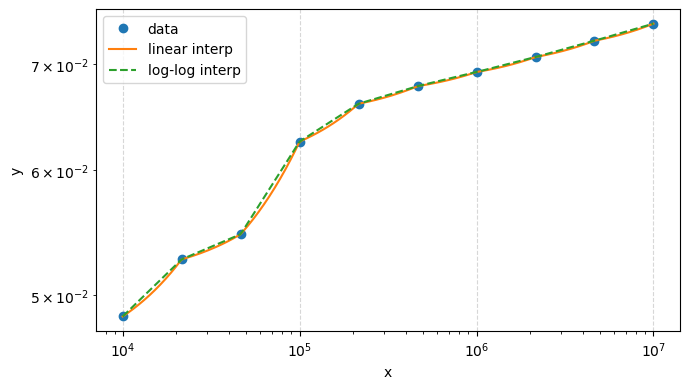

In [212]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Your data
data = [[10000.0, 0.04845151365236547],
        [21544.346900318822, 0.052658711779901966],
        [46415.88833612782, 0.05462411928022843],
        [100000.0, 0.0625252527074006],
        [215443.46900318822, 0.06606956403944185],
        [464158.8833612772, 0.06778588476300099],
        [1000000.0, 0.06919666505161384],
        [2154434.6900318824, 0.07072266224219022],
        [4641588.833612773, 0.07242570062836745],
        [10000000.0, 0.07425363103180765]]

# Split into x and y
x = np.array([d[0] for d in data])
y = np.array([d[1] for d in data])

# Create interpolation function (linear or log-log)
f_linear = interp1d(x, y, kind='linear')     # linear interpolation
f_log = interp1d(np.log10(x), np.log10(y), kind='linear')  # log-log

# Example: evaluate at new points
xnew = np.logspace(4, 7, 200)
ynew_linear = f_linear(xnew)
ynew_log = 10**f_log(np.log10(xnew))

# Optional: plot
plt.figure(figsize=(7,4))
plt.plot(x, y, 'o', label='data')
plt.plot(xnew, ynew_linear, '-', label='linear interp')
plt.plot(xnew, ynew_log, '--', label='log-log interp')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

## reproduce Mauricio plot 

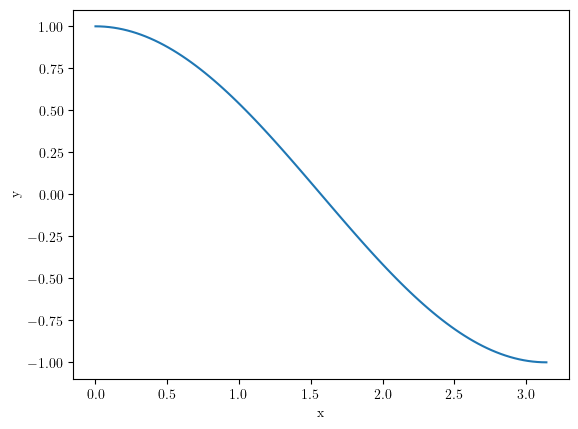

In [1185]:
# for phi in np.linspace(0,2*pi,10):
#     print(phi, scp.special.sph_harm(0,1,phi,np.pi/4))
#     sph_harm(m, l, phi, theta)
check_ylm = []
for th in np.linspace(0,pi,100):
    check_ylm.append([th, np.real(np.sqrt(4*pi/3)* scp.special.sph_harm(0,1,0,th))])
    
np.shape(check_ylm)

check_ylm = np.array(check_ylm)
plt.figure()
plt.plot(check_ylm[:, 0], check_ylm[:, 1])#, marker='.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Ylm works, I trust. 

In [1188]:
from scipy.special import sph_harm

### eq 6, 2503.15468
def H_LIV_paper(E,theta,phi,d,a_eff=None,c_eff=None):
    """
    Compute H_LIV_paper^(d) in flavor space.

    Parameters
    ----------
    E : float
        Neutrino energy
    theta, phi : float
        Direction of momentum (polar, azimuth)
    d : int
        Operator dimension
    a_eff, c_eff : dict
        LIV coefficients indexed as:
        coeff[(l, m)] -> 3x3 complex matrix in flavor space

    Returns
    -------
    H : (3,3) complex ndarray
        LIV Hamiltonian in flavor space
    """

    H = np.zeros((3, 3), dtype=complex)

    prefactor = E**(d - 3)

    for l in range(d):
        for m in range(-l, l + 1):

            Ylm = sph_harm(m, l, phi, theta)

            if d % 2 == 1:  # CPT-odd
                if a_eff is None or (l, m) not in a_eff:
                    continue
                H += prefactor * Ylm * a_eff[(l, m)]

            else:  # CPT-even
                if c_eff is None or (l, m) not in c_eff:
                    continue
                H -= prefactor * Ylm * c_eff[(l, m)]

    return H


In [1190]:
d = 4  # CPT-even
c_eff = {}
# initialize (l=2, m=2) coefficient matrix
c_22 = np.zeros((3, 3), dtype=complex)
# flavor indices: e=0, mu=1, tau=2
c_22[2, 2] = 1e-34  # GeV^{-2}

# store in coefficient dictionary
c_eff[(2, 2)] = c_22


# --------------------------------------------------
# Evaluate H_LIV
# --------------------------------------------------

E = 1e6            # GeV
theta = np.pi / 3 # polar angle
phi = np.pi / 4   # azimuthal angle

H_LIV_paper(E, theta, phi, d, c_eff=c_eff)

array([[ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        -1.77393549e-45-2.89705652e-29j]])

In [1254]:
# density rho_src
def rho_SFR(z):
    """
    Cosmic star formation rate density \dot{rho}_*(z)

    Units:
    rho_0 = Msun yr^{-1} Mpc^{-3}
    """

    # ----------------------------
    # Fixed parameters (eq 5 from 0804.4008)
    # ----------------------------
    rho0 = 1        # Msun yr^-1 Mpc^-3

    a = 3.4
    b = -0.3
    c = -3.5

    eta = -10.0

    # Break parameters
#     B = 5000
#     C = 9
    z1 = 1.0
    z2 = 4.0

    B = (1 + z1)**(1 - a / b)
    C = (1 + z1)**((b - a) / c) * (1 + z2)**(1 - b / c)

#     print(B,C)
    # ----------------------------
    # Star formation rate density
    # ----------------------------
    term1 = (1 + z)**(a * eta)
    term2 = ((1 + z) / B)**(b * eta)
    term3 = ((1 + z) / C)**(c * eta)

#     return rho0 * ( term1 +term2 + term3)
    return rho0 * (term1 + term2 + term3)**(1 / eta)


In [1249]:
rho_SFR(1),rho_SFR(40)

(9.849155306759242, 0.005078921487184344)

In [1229]:
del rho_SFR

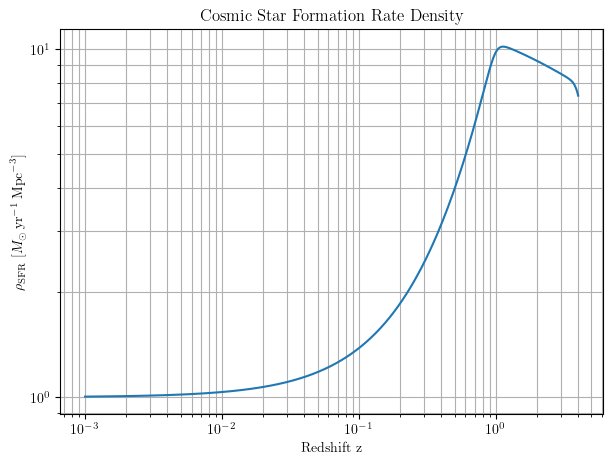

In [1207]:
z = np.logspace(-3, np.log10(4), 500)
rho = rho_SFR(z)

plt.figure(figsize=(7, 5))
plt.plot(z, rho)
plt.xlabel("Redshift z")
plt.ylabel(r"$\rho_{\rm SFR}\;[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}]$")
plt.xscale('log')
plt.yscale('log')
plt.title("Cosmic Star Formation Rate Density")
plt.grid(True, which="both")#, ls="--")
plt.show()


In [1255]:
from scipy.integrate import quad

# Constants
c = 3.0e5  # speed of light in km/s
H0 = 70.0  # Hubble constant in km/s/Mpc
Omega_m = 0.3  # Matter density parameter
Omega_Lambda = 0.7  # Dark energy density parameter

# Function for Hubble parameter H(z)
def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

# Comoving distance function D_c(z)
def D_c(z):
    integrand = lambda z_prime: c / (H0 * np.sqrt(Omega_m * (1 + z_prime)**3 + Omega_Lambda))
    result, _ = quad(integrand, 0, z)
    return result

# Volume element dV/dz
def dV_dz(z):
    return 4 * np.pi * D_c(z)**2 * c / H(z)

# Function to compute N(z_max)
def N(z_max):
    integrand = lambda z: (rho_SFR(z) * dV_dz(z)) / (1 + z)
    result, _ = quad(integrand, 1e-100, z_max)
    return result

# Example usage
z_max = 1.0  # You can change z_max to any value you're interested in
N_result = N(z_max)
print(f"The number of mergers up to z = {z_max} is: {N_result}")

z_max = 4.0  # You can change z_max to any value you're interested in
N_result = N(z_max)
print(f"The number of stars up to z = {z_max} is: {N_result}")

print(N(4)/N(1))

The number of mergers up to z = 1.0 is: 551084488177.7847
The number of mergers up to z = 4.0 is: 4392241344496.084
7.97017778348192


In [1262]:
import numpy as np
from scipy.integrate import quad

# ------------------------
# Cosmology
# ------------------------
H0 = 70.0  # km/s/Mpc
Omega_m = 0.3
Omega_L = 0.7

def h(z):
    """Dimensionless Hubble parameter H(z)/H0"""
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

# ------------------------
# Flavor transition probability
# Placeholder (standard oscillations or LIV-modified)
# ------------------------
def P_beta_to_alpha(E, beta, alpha, theta_std=None, Lambda_LIV=None):
    """
    Neutrino flavor transition probability
    Replace with your own oscillation/LIV model
    """
    # Example: averaged oscillations
    P_avg = {
        ('e', 'e'): 0.55, ('e', 'mu'): 0.23, ('e', 'tau'): 0.22,
        ('mu', 'e'): 0.23, ('mu', 'mu'): 0.39, ('mu', 'tau'): 0.38,
        ('tau', 'e'): 0.22, ('tau', 'mu'): 0.38, ('tau', 'tau'): 0.40
    }
    return P_avg[(beta, alpha)]

# ------------------------
# Flux computation
# ------------------------
def Phi_alpha(
    E, alpha,
    z_max=4.0,
    Phi0=1.0,
    gamma=2.7,
    f_beta_S={'e': 1.5/3, 'mu': 1.5/3, 'tau': 0/3},
    theta_std=None,
    Lambda_LIV=None
):
    """
    Compute diffuse neutrino flux Phi_alpha(E)
    """

    def integrand(z):
        Ez = E * (1 + z)

        flavor_sum = 0.0
        for beta in ['e', 'mu', 'tau']:
            P = P_beta_to_alpha(Ez, beta, alpha, theta_std, Lambda_LIV)
            flavor_sum += P * f_beta_S[beta]

        return (
            rho_SFR(z)
            / (h(z) * (1 + z)**2)
            * Ez**(2 - gamma)
            * flavor_sum
        )

    integral, _ = quad(integrand, 0, z_max, epsabs=1e-8)
    return Phi0 * integral / E**2

# ------------------------
# Example usage
# ------------------------
E = 1e9  # GeV
phi_mu = Phi_alpha(E, alpha='mu')

print(f"Phi_mu(E={E:.1e} GeV) = {phi_mu:.3e}")
Phi_alpha(E, alpha='e'),Phi_alpha(E, alpha='mu'),Phi_alpha(E, alpha='tau')

Phi_mu(E=1.0e+09 GeV) = 2.367e-25


(2.9784508586094264e-25, 2.3674865799203127e-25, 2.2911160450841737e-25)

## reproduce neutrino count: POEMMA

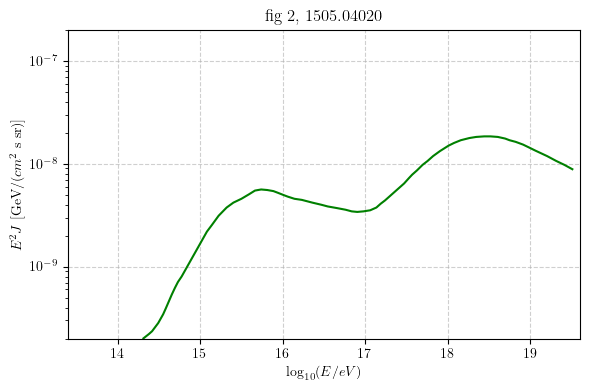

In [62]:
neuflux = pd.read_csv("neuflux_1505.04020/neuflux_SFR_proton_only.csv", 
                      header=None, names=["log10Enu", "rate"]) 

plt.figure(figsize=(6,4))
plt.plot(neuflux["log10Enu"], neuflux["rate"], linestyle='-', color='green')

plt.xlabel(r"$\log_{10} (E/eV)$")
plt.ylabel(r"$E^2 J$ [GeV/($cm^2$ s sr)]")
plt.yscale('log')
plt.ylim(2e-10,2e-7)
plt.xlim(13.4,19.6)
plt.title("fig 2, 1505.04020")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

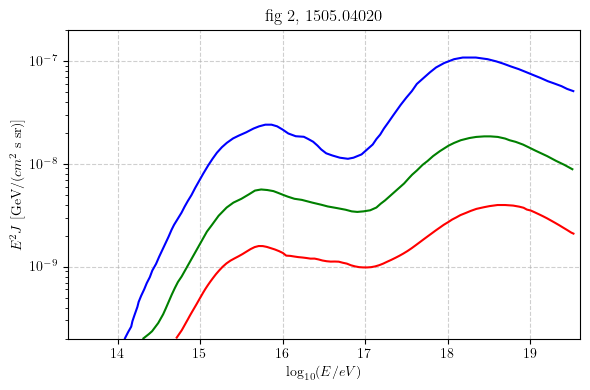

In [60]:
neuflux1 = pd.read_csv("neuflux_1505.04020/cosmo_nuflux_1505_04020_fig2_opt_AGN_blue_solid.csv", 
                      header=None, names=["log10Enu", "rate"]) 
neuflux2 = pd.read_csv("neuflux_1505.04020/cosmo_nuflux_1505_04020_fig2_mod_SFR_green_solid.csv", 
                      header=None, names=["log10Enu", "rate"]) 
neuflux3 = pd.read_csv("neuflux_1505.04020/cosmo_nuflux_1505_04020_fig2_pess_noEvol_red_solid.csv", 
                      header=None, names=["log10Enu", "rate"]) 

plt.figure(figsize=(6,4))
plt.plot(neuflux1["log10Enu"], neuflux1["rate"], linestyle='-', color='blue')
plt.plot(neuflux2["log10Enu"], neuflux2["rate"], linestyle='-', color='green')
plt.plot(neuflux3["log10Enu"], neuflux3["rate"], linestyle='-', color='red')

plt.xlabel(r"$\log_{10} (E/eV)$")
plt.ylabel(r"$E^2 J$ [GeV/($cm^2$ s sr)]")
plt.yscale('log')
plt.title("fig 2, 1505.04020")
plt.ylim(2e-10,2e-7)
plt.xlim(13.4,19.6)
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [46]:
E_eV = 10**neuflux["log10Enu"].values
rate = neuflux["rate"].values   # already GeV/(cm^2 s sr)")

# Build interpolation function: input E (eV) 
flux_interp = interp1d(
    E_eV,
    rate,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e15  # eV
print(f"flux at E = {E_test:.1e} eV : {flux_interp(E_test):.3e} GeV/(cm^2 s sr)")

flux at E = 1.0e+15 eV : 1.674e-09 GeV/(cm^2 s sr)


In [31]:
neuflux[15:18]

,log10Enu,rate
15,14.925373,1.309246e-09
16,14.985075,1.592677e-09
17,15.037313,1.890583e-09


In [11]:
poemma_area = pd.read_csv("eff_area/poemma_nutau_tau.csv", 
                      header=None, names=["log10Enu", "area"]) 

In [13]:
kmtocm = 1e5
E_eV = 10**poemma_area["log10Enu"].values
eff_area = poemma_area["area"].values * kmtocm**2   # cm^2 sr

# Build interpolation function: input E (eV) → 
area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

poemma_area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {area_interp(E_test):.3e} cm^2 sr")

area at E = 1.0e+17 eV : 7.172e+08 cm^2 sr


In [14]:
grand200k_area = pd.read_csv("eff_area/grand_200k.csv", 
                      header=None, names=["log10Enu", "area"]) 

E_eV = 1e9*grand200k_area["log10Enu"].values
eff_area = grand200k_area["area"].values    # cm^2 
print(np.log10(min(E_eV)),np.log10(max(E_eV)))
grand_area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {grand_area_interp(E_test):.3e} cm^2 sr")

16.999999999999996 20.0
area at E = 1.0e+17 eV : 7.475e+09 cm^2 sr


In [151]:
np.array(effareadata_ICgen2radio)[:,0]

array([3.16227766e+07, 1.00000000e+08, 3.16227766e+08, 1.00000000e+09,
       3.16227766e+09, 1.00000000e+10, 3.16227766e+10, 1.00000000e+11,
       3.16227766e+11])

In [409]:
(1e9)**2 * 2.44 /(1e9 * 10*year*np.log(10) * 4*np.pi * 2.99916e8)

8.915753062934841e-10

In [15]:
# --- IceCube Gen2 Radio effective area data (GeV, cm^2) ---
effareadata_ICgen2radio = [
    [10**7.5, 4.06024e6],
    [10**8.0, 4.06024e6],
    [10**8.5, 4.75677e7],
    [10**9.0, 2.99916e8],
    [10**9.5, 1.15092e9],
    [10**10.0, 3.11424e9],
    [10**10.5, 6.63344e9],
    [10**11.0, 1.21362e10],
    [10**11.5, 2.03881e10],
]

# --- Build interpolation in log-log space (E in eV, A in cm^2) ---
E_eV_list = 1e9 * np.array([x for x, _ in effareadata_ICgen2radio])
A_cm2_list = np.array([y for _, y in effareadata_ICgen2radio])
print(A_cm2_list)
_area_interp = interp1d(np.log10(E_eV_list), np.log10(A_cm2_list), kind='linear', fill_value='extrapolate')

# def ICgen2radio_area_interp(E_eV):
#     """Effective area [cm^2] of IceCube Gen2 Radio vs energy [eV]."""
    
#     if E_eV < np.min(E_eV_list):
#         return 0
    
#     elif E_eV > np.max(E_eV_list):
#         return 0
    
#     else:
#         return 10 ** _area_interp(np.log10(E_eV))

def ICgen2radio_area_interp(E_eV):
    """Effective area [cm^2] of IceCube Gen2 Radio vs energy [eV]."""

    E = np.asarray(E_eV)  # handles float or array input

    Emin = np.min(E_eV_list)
    Emax = np.max(E_eV_list)

    # Initialize output array
    out = np.zeros_like(E, dtype=float)

    # Valid energy region (boolean mask)
    mask = (E >= Emin) & (E <= Emax)

    # Interpolate only where valid
    out[mask] = 10 ** _area_interp(np.log10(E[mask]))

    # If original input was scalar, return scalar
    return out.item() if np.isscalar(E_eV) else out

# Example:
if __name__ == "__main__":
    E_test = 1e19  # eV
    print(f"A_eff({E_test:.2e} eV) = {poemma_area_interp(E_test),ICgen2radio_area_interp(E_test)} cm^2")

[4.06024e+06 4.06024e+06 4.75677e+07 2.99916e+08 1.15092e+09 3.11424e+09
 6.63344e+09 1.21362e+10 2.03881e+10]
A_eff(1.00e+19 eV) = (array(1.42436829e+11), 3114239999.999997) cm^2


In [210]:
ICgen2radio_area_interp(1e1)

0.0

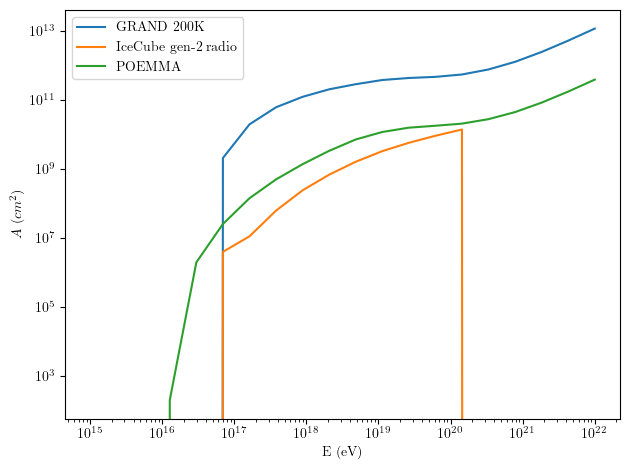

In [16]:
elist = np.logspace(9+6,9+13,20)
plt.plot(elist,grand_area_interp(elist),label='GRAND 200K')
plt.plot(elist,ICgen2radio_area_interp(elist),label='IceCube gen-2 radio')
plt.plot(elist,poemma_area_interp(elist)/(4*np.pi),label='POEMMA')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('E (eV)')
plt.ylabel(r'$A ~(cm^2)$')
plt.legend()
plt.tight_layout()

In [32]:
neuflux[20:22]

,log10Enu,rate
20,15.223881,3.123783e-09
21,15.320896,3.753774e-09


In [18]:
# Integration limits in eV
E_min = 1e15      # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV
year = 365*24*3600
# Define the integrand_flux_area
def integrand_flux_area(E):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    return flux_interp(E) * area_interp(E) * unit_refiner    # 1/(s)

# Perform the integral
result, err = quad(integrand_flux_area, E_min, E_max, limit=500, epsabs=0, epsrel=1e-4)

print(f"Integral = {result:.3e}  (same units as flux × area × eV)")
print(f"Estimated absolute error = {err:.1e}")

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('tau count:', result * 5*year*0.20/3) 

Integral = 1.245e-06  (same units as flux × area × eV)
Estimated absolute error = 5.3e-11
tau count: 13.083310417281368


In [17]:
neu_reach = pd.read_csv("neuflux_1505.04020/poemma_sensitivity_photonby10_green.csv", 
                      header=None, names=["log10Enu", "reach"]) 

E_eV = 10**neu_reach["log10Enu"].values
reach = neu_reach["reach"].values   # already GeV/(cm^2 s sr)

# Build interpolation function: input E (eV) → 
reach_interp = interp1d(
    E_eV,
    reach,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {reach_interp(E_test):.3e} GeV/(cm^2 s sr)")

area at E = 1.0e+17 eV : 6.776e-10 GeV/(cm^2 s sr)


In [17]:
flux_interp(E_test) - reach_interp(E_test) , np.heaviside(flux_interp(E_test) - reach_interp(E_test), 0)

(2.789448350996802e-09, 1.0)

In [18]:
neu_reach[28:31]

,log10Enu,reach
28,16.998912,6.781493e-10
29,17.069724,6.415476e-10
30,17.192072,5.903157e-10


In [19]:
flux_interp(E_min), area_interp(E_min)

(array(1.6741687e-09), array(-311713.7481598))

In [21]:
area_interp(13e15),area_interp(12e15)

(array(4339.53807054), array(-6407.48364201))

In [19]:
# Integration limits in eV
E_min = 13e15 # choice from plot when reach can access cosmogenic flux # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV
year = 365*24*3600
# Define the integrand
def integrand_count(E):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2 for flux, 1/GeV to 1/eV
    return flux_interp(E) * area_interp(E) * unit_refiner    # unit GeV^-1 s^-1

# Perform the integral
result, err = quad(integrand_count, E_min, E_max, limit=300, epsabs=0, epsrel=1e-4)

print(f"Integral = {result:.3e}  (same units as flux × area × eV)")
print(f"Estimated absolute error = {err:.1e}")

# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('tau count:', result * 5*year*0.20/3) 

Integral = 1.245e-06  (same units as flux × area × eV)
Estimated absolute error = 7.1e-11
tau count: 13.091838531665823


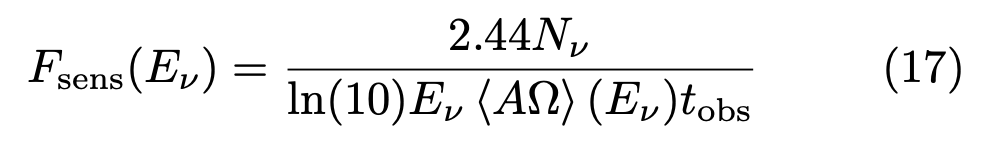

In [517]:
def Fsens(E):
    main1 = (2.44*3)/(np.log(10)*E*area_interp(E) *5*year * 0.2) # 1 / eV cm^2 sr s
    main2 = E**2 * main1 # eV / cm^2 sr s
    main3 = 1e-9 * main2 # GeV / cm^2 sr s
    return main3
    
Fsens(1e17)

1.4054602828830414e-08

In [519]:
reach_interp(1e17)

array(6.77630752e-10)

In [580]:
area_interp(1e17) + (3.35e-3 + 2.62e-4)*kmtocm**2

def Fsens17():
    E=1e17
    main1 = (2.44)/(np.log(10)*E*(area_interp(1e17) + (3.35e-3 + 2.62e-4)*kmtocm**2) 
                      *5*year ) # 1 / eV cm^2 sr s
    main2 = E**2 * main1 # eV / cm^2 sr s
    main3 = 1e-9 * main2 # GeV / cm^2 sr s
    return main3
    
Fsens(1e17), Fsens17(), reach_interp(1e17)

(1.4054602828830414e-08, 8.920506958325442e-10, array(6.77630752e-10))

## multiple detectors

In [47]:
# Define the integrand_flux_area
def integrand_flux_area_exp(E,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp(E) * area_factor * unit_refiner    # 1/(s)

In [648]:
## trial flux, unit


# Define the integrand_flux_area
def integrand_flux_area_expv2(E,exp):
    EnuGeV = E #* 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) #* 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E*1e9)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E*1e9)
    if exp=='grand200k':
        area_factor=grand_area_interp(E*1e9)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp(E) * area_factor * unit_refiner    # 1/(s)

E_min = 1e6        # 1 PeV = 1e15 eV
E_max = 1e11      # 100 EeV = 1e20 eV
print(integrand_flux_area_expv2(1e9,'poemma'))
result, err = quad(integrand_flux_area_expv2, 
                   E_min, E_max, 
                   args=('poemma',), 
                   limit=500, epsabs=0, epsrel=1e-4)


# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )

poemma_area_interp(1e18), ICgen2radio_area_interp(1e18), grand_area_interp(1e18)

1.553357011470487e-18
poemma tau count: 0.082


(array(2.00993996e+10), 299916000.0000004, array(1.37344495e+11))

In [654]:
# Perform the integral
E_min = 1e15        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('poemma',), 
                   limit=500, epsabs=0, epsrel=1e-4)


# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )

poemma tau count: 13.092


In [613]:
# Perform the integral
E_min = 1e15        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
#                    10**15.5,1e20,
                   args=('ICgen2radio',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16, https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor 
print('ICgen2radio tau count:', np.round(result * 4*np.pi *10*year/3, 3) ) 

ICgen2radio tau count: 28.018


In [603]:
[x/1e10 for x in [poemma_area_interp(1e18), 
 ICgen2radio_area_interp(1e18)* 4*np.pi, 
 grand_area_interp(1e18)]]

[2.009939959038157, 0.3768855609176151, 13.734449456480794]

In [591]:
# Integration limits in eV
E_min = 1e15      # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

# Perform the integral
result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('grand tau count:', np.round(result * 1*year/3, 3) )

grand tau count: 66.917


In [594]:
E_min = 1e18        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('POEMMA paper --> grand tau count:', np.round(result * 10*year/3, 3) )

POEMMA paper --> grand tau count: 384.432


## make histogram

In [818]:
# Perform the integral
E_min = 1e15        # 1 PeV = 1e15 eV
E_max = 100000e15      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('poemma',), 
                   limit=500, epsabs=0, epsrel=1e-4)

print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

print('grand tau count:', np.round(result * 10*year/3, 3) )

poemma tau count: 13.092
grand tau count: 669.165


In [865]:
np.random.uniform(0.0, 100.0)

41.32019634154819

In [870]:
sbig = 0
ssmall = 0
for k in range(10000):
    O_custom = [np.random.uniform(0.0, 100.0), np.random.uniform(0.0, 100.0)]
    Lambda_custom = [1e18, 1e18]
    
    nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                             dm21, dm31,
                             n_terms=len(O_custom),
                             O_n_list=O_custom,
                             Lambda_n_list=Lambda_custom,
                             seed=k)
    
    for emin in [10**x for x in range(15,20,1)]: 

        avg_ratio = (nu.flavor_ratio([1,0,0], emin)[2] 
                     + nu.flavor_ratio([1,0,0], 10*emin)[2])/2/3 
        if avg_ratio>1/3:
            sbig += 1
            print(k, emin, avg_ratio)
        
    if avg_ratio<1/3:
        ssmall += 1

    if avg_ratio < 0.1: 
        print(k)

    if k%1000==0:
        print(f"{k} done")

0
0 done
1
2
3
4
6
7
8
9
10
11
15
16
17
20
21
23
25
26
27
28
29
33
34
35
38
39
40
41
42
45
46
47
48
49
50
51
57
59
60
61
63
64
65
67
68
69
70
71
73
74
75
76
77
78
80
81
82
84
87
88
89
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
113
115
116
117
118
120
121
122
123
124
125
126
127
129
130
132
133
135
136
137
140
141
142
143
144
145
148
149
152
153
154
155
156
159
161
163
165
166
167
168
172
173
174
176
178
179
180
181
184
185
186
187
188
190
191
192
195
196
197
204
205
206
207
208
210
211
213
214
216
217
221
222
224
225
226
227
230
231
232
233
234
236
237
238
239
241
242
243
244
245
246
247
248
249
251
253
254
255
256
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
279
280
281
283
284
290
292
293
296
300
301
303
304
305
307
310
311
312
316
317
318
319
323
326
328
329
330
331
332
333
335
337
338
339
342
344
345
347
348
349
351
352
353
354
356
359
360
366
367
368
369
370
372
378
381
382
383
384
385
386
387
389
390
391
393
394
395
396


2724
2725
2726
2727
2728
2729
2730
2732
2733
2735
2738
2741
2742
2744
2746
2747
2748
2750
2751
2752
2753
2754
2755
2756
2757
2758
2759
2760
2762
2763
2764
2765
2766
2767
2768
2771
2772
2773
2775
2776
2778
2779
2780
2782
2787
2790
2792
2794
2795
2796
2797
2798
2799
2801
2802
2804
2805
2807
2808
2809
2810
2812
2813
2814
2815
2816
2817
2818
2819
2820
2821
2823
2826
2827
2829
2832
2833
2834
2836
2837
2838
2839
2840
2841
2847
2848
2849
2850
2853
2854
2855
2856
2857
2858
2860
2861
2862
2863
2864
2865
2867
2868
2869
2870
2872
2873
2876
2877
2878
2879
2880
2881
2882
2883
2884
2886
2887
2888
2889
2890
2891
2892
2893
2897
2898
2899
2900
2901
2904
2906
2907
2908
2912
2913
2915
2916
2918
2921
2922
2926
2927
2929
2930
2931
2932
2934
2935
2936
2937
2939
2941
2942
2943
2944
2946
2947
2948
2949
2950
2952
2953
2954
2955
2956
2957
2959
2960
2961
2963
2965
2967
2968
2969
2971
2972
2973
2976
2979
2980
2981
2982
2983
2985
2986
2988
2989
2990
2991
2992
2993
2994
2995
2996
2999
3000
3000 done
3002
3003
3007


5205
5206
5207
5209
5212
5213
5214
5216
5217
5218
5219
5222
5223
5224
5225
5228
5229
5230
5231
5233
5234
5235
5237
5238
5239
5240
5241
5243
5244
5245
5246
5248
5249
5254
5255
5259
5260
5262
5263
5264
5265
5266
5268
5269
5271
5272
5274
5276
5278
5279
5280
5281
5283
5284
5285
5286
5288
5290
5291
5292
5293
5296
5297
5298
5299
5300
5301
5302
5303
5304
5306
5307
5308
5309
5312
5314
5316
5318
5319
5320
5321
5322
5323
5324
5325
5326
5327
5329
5330
5331
5332
5333
5335
5336
5337
5338
5339
5340
5341
5343
5344
5345
5347
5348
5350
5351
5352
5353
5355
5356
5357
5358
5359
5360
5363
5364
5366
5368
5369
5370
5371
5372
5373
5374
5375
5377
5380
5381
5383
5385
5386
5387
5389
5390
5391
5392
5393
5394
5395
5399
5400
5402
5403
5405
5407
5408
5409
5410
5411
5412
5413
5415
5416
5417
5418
5419
5423
5424
5425
5426
5428
5429
5431
5432
5434
5435
5436
5440
5441
5442
5444
5445
5446
5448
5449
5450
5452
5453
5454
5457
5458
5459
5460
5462
5463
5465
5466
5467
5471
5472
5473
5474
5476
5477
5479
5480
5483
5484
5485
5487


7797
7798
7799
7800
7802
7803
7804
7805
7807
7808
7810
7811
7814
7816
7817
7818
7822
7823
7824
7825
7826
7827
7828
7829
7830
7831
7832
7833
7834
7835
7836
7838
7839
7841
7843
7847
7848
7849
7850
7851
7853
7854
7855
7857
7858
7859
7861
7863
7864
7865
7867
7868
7870
7871
7873
7876
7877
7878
7880
7881
7882
7883
7884
7885
7888
7892
7893
7894
7895
7896
7897
7899
7900
7906
7907
7908
7909
7910
7911
7912
7915
7916
7917
7918
7919
7920
7922
7923
7926
7927
7930
7931
7932
7933
7935
7936
7937
7938
7939
7941
7942
7943
7944
7947
7948
7949
7950
7951
7952
7953
7954
7956
7957
7958
7959
7960
7961
7965
7967
7970
7973
7974
7979
7981
7982
7983
7987
7988
7989
7991
7992
7994
7995
7996
7997
7998
8000
8000 done
8003
8005
8007
8008
8009
8013
8014
8015
8016
8017
8018
8020
8021
8022
8023
8024
8025
8026
8027
8028
8029
8030
8031
8033
8034
8035
8036
8037
8038
8039
8040
8041
8042
8044
8045
8048
8052
8053
8054
8055
8056
8058
8059
8060
8062
8063
8064
8066
8068
8072
8073
8074
8075
8076
8077
8078
8079
8081
8082
8084
8085


In [920]:
k

9999

In [926]:
O_custom = [np.random.uniform(0.0, 1e-20), np.random.uniform(0.0, 1e-25)]
Lambda_custom = [1e18, 1e18]

nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31,
                         n_terms=len(O_custom),
                         O_n_list=O_custom,
                         Lambda_n_list=Lambda_custom,
                         seed=9999)

ini_ratio = [1,2,0]

for emin in [10**x for x in range(15,20,1)]: 

    avg_ratio = (nu.flavor_ratio(ini_ratio, emin)[2] 
                 + nu.flavor_ratio(ini_ratio, 10*emin)[2])/2/sum(ini_ratio)
#     if avg_ratio>1/3:
#         sbig += 1
    print(540, emin, avg_ratio)


540 1000000000000000 0.31908602851257034
540 10000000000000000 0.3246265396015932
540 100000000000000000 0.3100441951055859
540 1000000000000000000 0.1944304142059169
540 10000000000000000000 0.14028212735280646


In [987]:
np.random.random(1,10)

TypeError: random() takes at most 1 positional argument (2 given)

In [1028]:
s=0
# Example usage
theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.307)), 
                              np.arcsin(np.sqrt(0.02195)), 
                              np.arcsin(np.sqrt(0.561))]

delta_cp = 0
dm21, dm31 = 7.49e-5, 2.534e-3
phi0 = np.array([1, 2, 0])  # initial flavor ratio

# Example user-supplied new physics:
O_custom = [np.random.uniform(0.0, 1e-20), np.random.uniform(0.0, 1e-25)]
Lambda_custom = [1e18, 1e18]
print(O_custom, np.random.uniform(0.0, 1e-20))
nu = NeutrinoHamiltonian(theta12, theta13, theta23, delta_cp,
                         dm21, dm31,
                         n_terms=len(O_custom),
                         O_n_list=O_custom,
                         Lambda_n_list=Lambda_custom,
                         seed=9999)

ini_ratio = [1,2,0]

histo_grand200k = []
histo_grand200k_LIV = []
for emin in [10**x for x in range(15,20,1)]: 
    result, err = quad(integrand_flux_area_exp, 
                   emin, 10*emin, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

#     print('grand tau count:', np.round(result * 10*year*1/3, 3) )
    histo_grand200k.append([emin,result * 10*year*1/3])
    
    ini_ratio = [1,2,0]
    avg_ratio = (nu.flavor_ratio(ini_ratio, emin)[2] 
                 + nu.flavor_ratio(ini_ratio, 10*emin)[2])/2/sum(ini_ratio)
    # 1/2 to avg, 1/sum(ini_ratio) to normalize sum to 1
    histo_grand200k_LIV.append([emin,result * 10*year*avg_ratio])
    print(avg_ratio)

histo_grand200k = np.array(histo_grand200k)
histo_grand200k_LIV = np.array(histo_grand200k_LIV)

[4.659315723846928e-21, 2.1505417932075533e-26] 5.931813047920231e-24
0.31908602851257034
0.3246265396015932
0.3100441951055859
0.1944304142059169
0.14028212735280646


In [929]:
s=0
histo_poemma = []
histo_poemma_LIV = []
for emin in [10**x for x in range(15,20,1)]: 
    result, err = quad(integrand_flux_area_exp, 
                   emin, 10*emin, 
                   args=('poemma',), 
                   limit=500, epsabs=0, epsrel=1e-4)

#     print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )
    histo_poemma.append([emin,result * 5*year*0.20/3])
    
    ini_ratio = [1,2,0]
    avg_ratio = (nu.flavor_ratio(ini_ratio, emin)[2] 
                 + nu.flavor_ratio(ini_ratio, 10*emin)[2])/2/sum(ini_ratio)
    # 1/2 to avg, 1/sum(ini_ratio) to normalize sum to 1
    histo_poemma_LIV.append([emin,result * 5*year*0.20*avg_ratio])
    print(avg_ratio)

histo_poemma = np.array(histo_poemma)
histo_poemma_LIV = np.array(histo_poemma_LIV)

0.3293197691614847
0.31695387490928567
0.28679749038269575
0.21261896418773144
0.1421218528597817


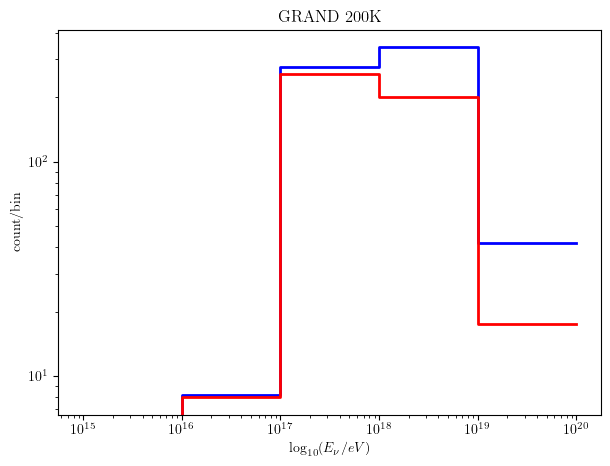

In [930]:
data = np.copy(histo_grand200k)
data_LIV = np.copy(histo_grand200k_LIV)

bin_starts = data[:,0]
heights    = data[:,1]
bin_edges = np.concatenate([bin_starts, [bin_starts[-1] * 10]])
widths = np.diff(bin_edges)

plt.figure(figsize=(7,5))
plt.step(bin_edges, np.append(heights, heights[-1]),
         where='post', linewidth=2, color='b')

heights_LIV = data_LIV[:,1]
plt.step(bin_edges, np.append(heights_LIV, heights_LIV[-1]),
         where='post', linewidth=2, color='r')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\log_{10} ({E_\nu/eV})$")
plt.ylabel("count/bin")
# plt.grid(True, which='both', ls='--')
plt.title("GRAND 200K")

plt.show()

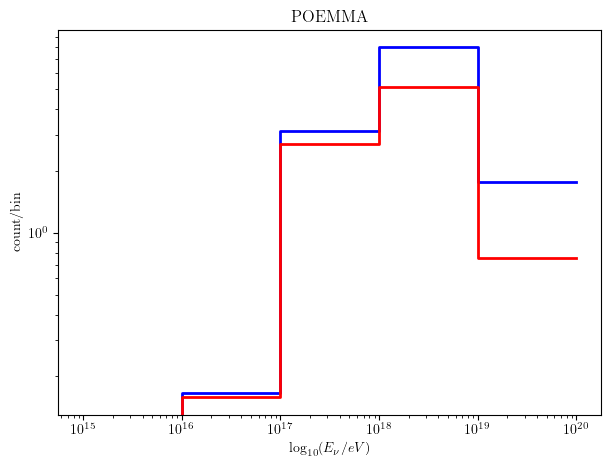

In [931]:
data = np.copy(histo_poemma)
data_LIV = np.copy(histo_poemma_LIV)

bin_starts = data[:,0]
heights    = data[:,1]
bin_edges = np.concatenate([bin_starts, [bin_starts[-1] * 10]])
widths = np.diff(bin_edges)

plt.figure(figsize=(7,5))
plt.step(bin_edges, np.append(heights, heights[-1]),
         where='post', linewidth=2, color='b')

heights_LIV = data_LIV[:,1]
plt.step(bin_edges, np.append(heights_LIV, heights_LIV[-1]),
         where='post', linewidth=2, color='r')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\log_{10} ({E_\nu/eV})$")
plt.ylabel("count/bin")
# plt.grid(True, which='both', ls='--')
plt.title("POEMMA")

plt.show()

## grand 

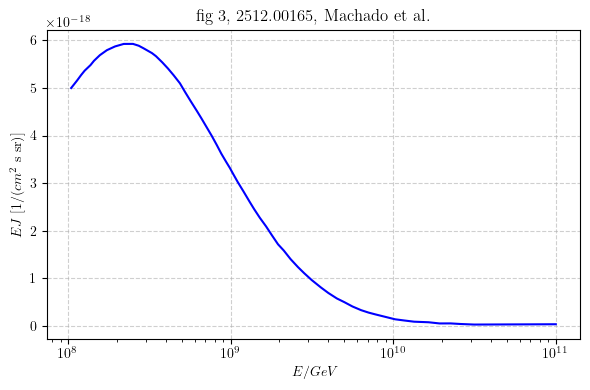

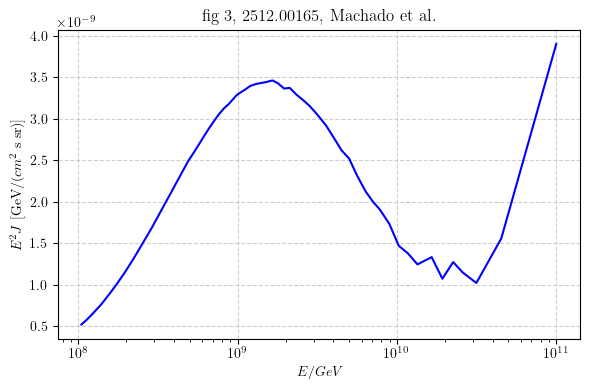

In [21]:
neuflux = pd.read_csv("neuflux_pedro_2512_00165_fig3.csv", 
                      header=None, names=["Enu", "rate"]) 

plt.figure(figsize=(6,4))
plt.plot(neuflux["Enu"], neuflux["rate"], linestyle='-', color='blue')

plt.xlabel(r"$E/GeV$")
plt.ylabel(r"$E J$ [1/($cm^2$ s sr)]")
plt.xscale('log')
plt.title("fig 3, 2512.00165, Machado et al.")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(neuflux["Enu"], neuflux["Enu"] * neuflux["rate"], linestyle='-', color='blue')

plt.xlabel(r"$E/GeV$")
plt.ylabel(r"$E^2 J$ [GeV/($cm^2$ s sr)]")
plt.xscale('log')
plt.title("fig 3, 2512.00165, Machado et al.")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [53]:
E_eV = 1e9*neuflux["Enu"].values
rate = (neuflux["Enu"] * neuflux["rate"]).values   # already GeV/(cm^2 s sr)")

# Build interpolation function: input E (eV) 
flux_interp_pedro = interp1d(
    E_eV,
    rate,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e20  # eV
print(f"flux at E = {E_test:.1e} eV : {flux_interp(E_test):.3e} GeV/(cm^2 s sr)")
print(f"flux at E = {E_test:.1e} eV : {flux_interp_pedro(E_test):.3e} GeV/(cm^2 s sr)")

flux at E = 1.0e+20 eV : -7.448e-10 GeV/(cm^2 s sr)
flux at E = 1.0e+20 eV : 3.891e-09 GeV/(cm^2 s sr)


In [81]:
# Define the integrand_flux_area
def integrand_fluxpedro_area_exp(E,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp_pedro(E) * area_factor * unit_refiner    # 1/(s)

In [120]:
# Integration limits in eV
E_min = 1e16      # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV
year = 365*24*3600

# Perform the integral
result, err = quad(integrand_fluxpedro_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('grand tau count:', np.round(result * 1*year/3, 3) )

# Perform the integral
result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('grand tau count:', np.round(result * 1*year/3, 3) )

grand tau count: 13.49
grand tau count: 66.917


/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_58172/4101534225.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, err = quad(integrand_flux_area_exp,


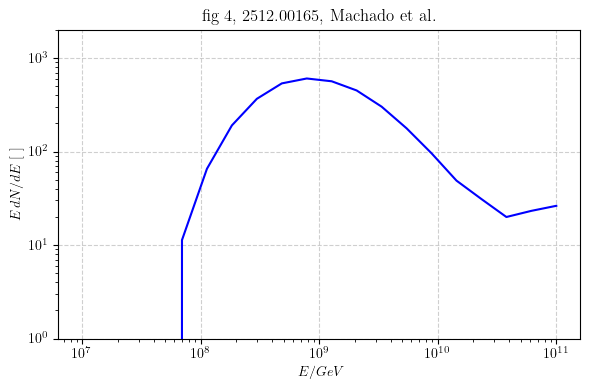

In [106]:
def dNdE_pedro(E,Tobs,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) #* 1e-9 
    #factor explanaton: 1/E^2 , unit remains 1/GeV, no factor 1e-9 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)

    area_factor = np.maximum(area_factor, 0)
        
#     return  4*np.pi * Tobs * area_factor * flux_interp(E)/3 * unit_refiner  
    return  4*np.pi * Tobs * area_factor * flux_interp_pedro(E)/3 * unit_refiner
    # unit 1/(GeV)

def EtimesdNdE_pedro(E,Tobs,exp):
    return E*1e-9 * dNdE_pedro(E,Tobs,exp)

E=1e18
EtimesdNdE_pedro(E,10*year,'grand200k')

plt.figure(figsize=(6,4))

elist_eV = np.logspace(9+7,9+11,20)
elist_GeV = (1e-9 * elist_eV)
plt.plot(elist_GeV, EtimesdNdE_pedro(elist_eV,10*year,'grand200k'),label='Pedro, GRAND',
         linestyle='-', color='blue')
# plt.plot(elist_GeV, flux_interp_pedro(elist_eV),label='Pedro, GRAND',
#          linestyle='-', color='blue')
# plt.plot(elist_GeV, flux_interp(elist_eV),label='Pedro, GRAND',
#          linestyle='-', color='red')

plt.xlabel(r"$E/GeV$")
plt.ylabel(r"$E \,dN/dE$ [ ]")
plt.xscale('log')
plt.yscale('log')
plt.ylim(1,2e3)
plt.title("fig 4, 2512.00165, Machado et al.")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


lower tail doesn't match since lower tail neutrino flux not given to digitize.

upper tail doesn't match because E being multiplied... not sure. 

In [126]:
year*integrand_flux_area_exp(1e18,'grand200k')

6.430641338966424e-17

In [131]:
# Integration limits in eV
E_min = 1e18        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('POEMMA paper --> grand tau count:', np.round(result * 10*year/3, 3) )


def dNdE_log_integrand(E_eV_exponent, Tobs, exp):
    E_eV = 10**(E_eV_exponent)
    return dNdE_pedro(E_eV, Tobs, exp)* (1/1e9) * E_eV   # Jacobian!

x_min = np.log10(E_min)
x_max = np.log10(E_max)
result, err = quad(
    dNdE_log_integrand,
    x_min, x_max,
    args=(10*year, 'grand200k'),
    epsabs=0, epsrel=1e-4, limit=500)
print('Pedro paper --> grand tau count:', np.round(result, 3) )


POEMMA paper --> grand tau count: 384.432
Pedro paper --> grand tau count: 362.819


## sensitivity 

eq 1 from *1807.01820*

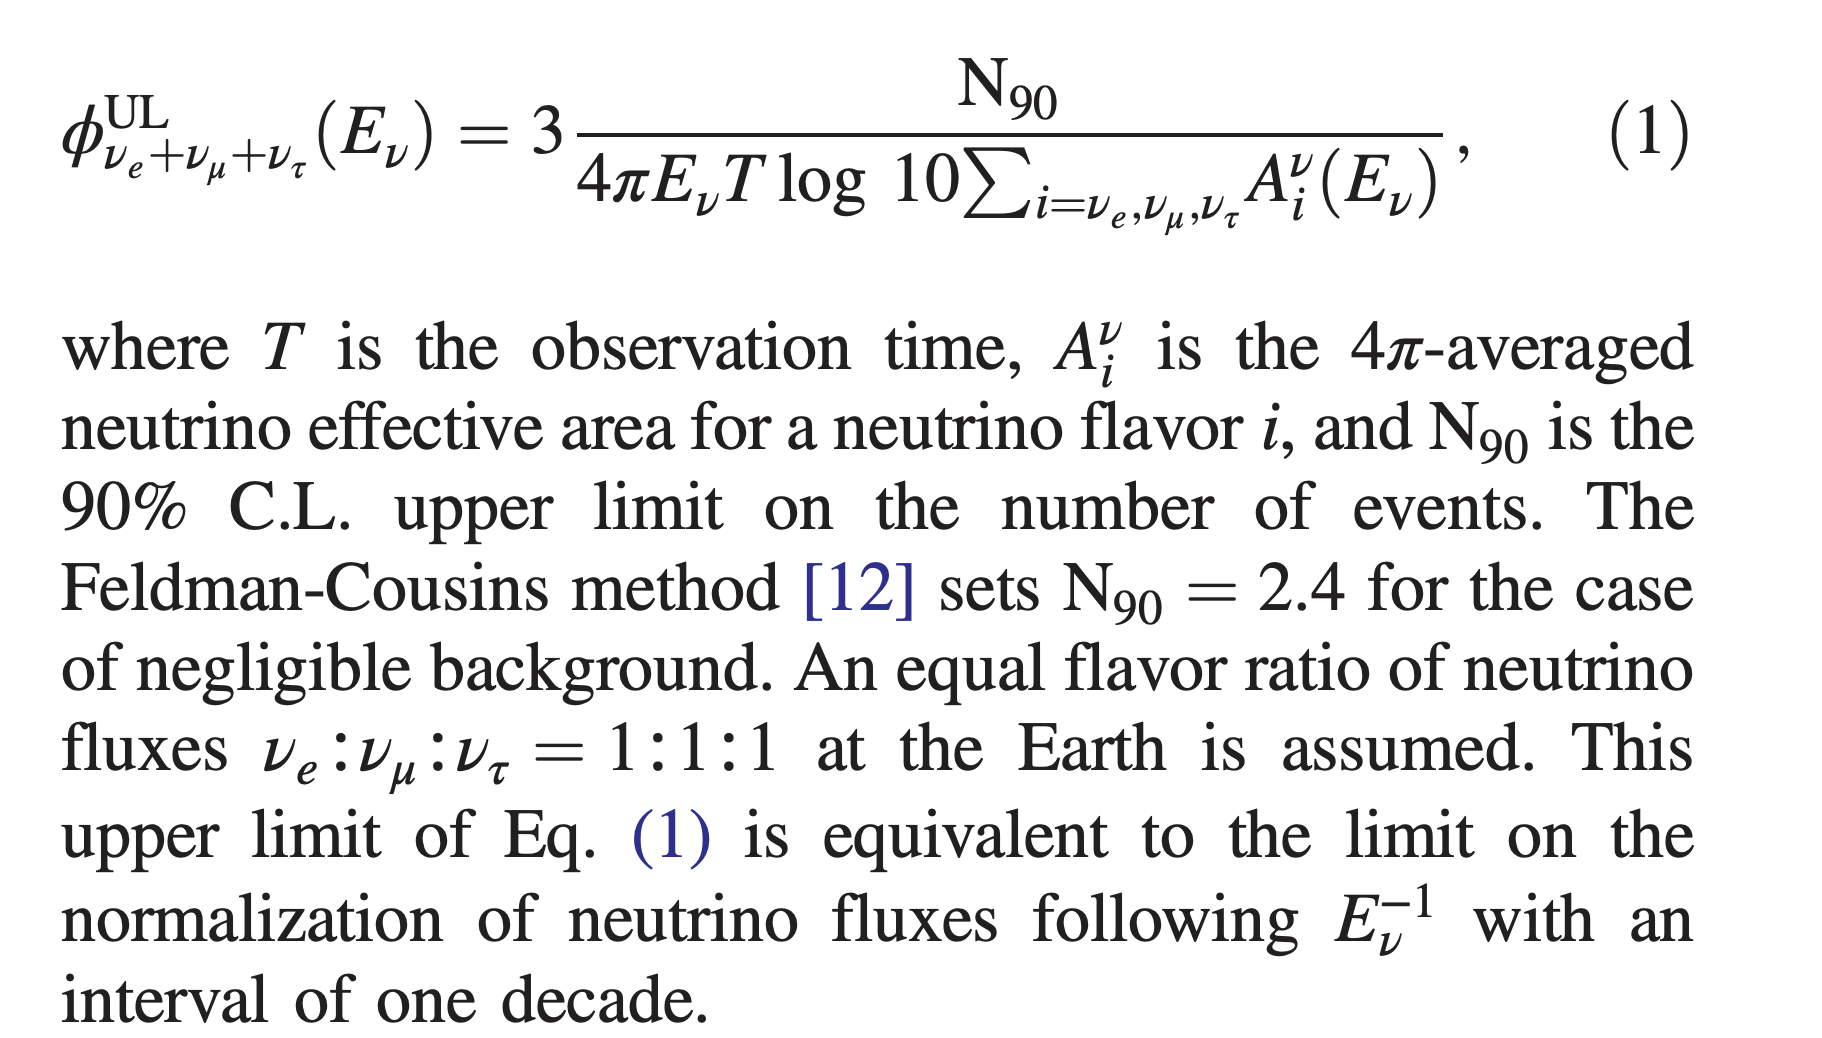

In [134]:
area_interp(1e19)

array(1.42436829e+11)

In [326]:
del E2Phi_3flavors

In [348]:
np.log(10)

2.302585092994046

In [23]:
# del E2Phi_3flavors
def E2Phi_3flavors(E_GeV, exp, Tobs, Nnu=3):

    # formula: eq.19, https://arxiv.org/pdf/1902.11287
    N90 = 2.44
    E_eV = E_GeV * 1e9
    if exp=='poemma':
        area_factor = poemma_area_interp(E_eV)
    if exp=='ICgen2radio':
        area_factor = 4*np.pi * ICgen2radio_area_interp(E_eV)
    if exp=='grand200k':
        area_factor = grand_area_interp(E_eV)

#     area_factor is A*Omega
    area_factor = np.maximum(area_factor, 1e-100)
    
    denom = E_GeV * Tobs * np.log(10) * area_factor 
    # return E_GeV**2 /area_factor
    return E_GeV**2 * Nnu * N90/denom 


In [5]:
def E2Phi_3flavors_bin(E_GeV_bin_upper, E_GeV_bin_lower, exp, Tobs, Nnu=3):

    # formula: eq.19, https://arxiv.org/pdf/1902.11287
    N90 = 2.44
    E_GeV_mean = (E_GeV_bin_upper + E_GeV_bin_lower)/2
    E_eV = E_GeV_mean * 1e9
    if exp=='poemma':
        area_factor = poemma_area_interp(E_eV)
    if exp=='ICgen2radio':
        area_factor = 4*np.pi * ICgen2radio_area_interp(E_eV)
    if exp=='grand200k':
        area_factor = grand_area_interp(E_eV)

#     area_factor is A*Omega
    area_factor = np.maximum(area_factor, 1e-100)
    delta_E = E_GeV_bin_upper - E_GeV_bin_lower
    denom = delta_E * Tobs * np.log(10) * area_factor 
    return E_GeV_mean**2 * Nnu * N90/denom 

In [522]:
ICgen2radio_area_interp(1e9*1e9)/1e8, E2Phi_3flavors(1e9,'ICgen2radio', 10*year*3)/3

(2.9991600000000043, 2.9719176876449435e-10)

In [24]:
E2Phi_3flavors(1e9,'ICgen2radio',10*year*3,1)/0.5

5.943835375289887e-10

In [25]:
print((1e9)**2 * 2.44 /(1e9 * 10*year*np.log(10) * 4*np.pi * 3* 2.99916e8 * 0.5))
print(E2Phi_3flavors(1e9,'ICgen2radio',10*year*3,1)/0.5)

print((1e9)**2 * 2.44 /(1e9 * 10*year*np.log(10) * 4*np.pi * 2.99916e8))
print(E2Phi_3flavors(1e9,'ICgen2radio',10*year,1))

5.943835375289895e-10
5.943835375289887e-10
8.915753062934841e-10
8.915753062934831e-10


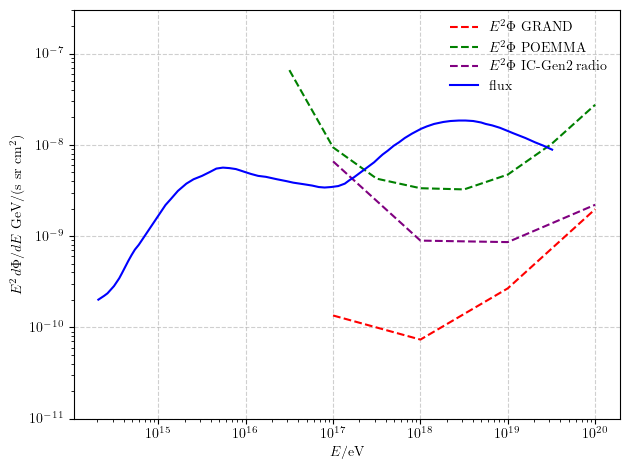

In [37]:
elist_eV = [10.**(9+7+x*1.) for x in range(1,4+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
plt.loglog(elist_eV, 
           E2Phi_3flavors(elist_GeV,'grand200k',10*year,3),#/elist_GeV**2,
         label=r'$E^2 \Phi$ GRAND',
         linestyle='--', color='red')

elist_eV = [10**(9+7+x*0.5) for x in range(1,8+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
plt.loglog(elist_eV, 
           E2Phi_3flavors(elist_GeV,'poemma', 
                          0.2* 5*year*0.5,1),#/elist_GeV**2, # 0.2 duty cycle=20%
         label=r'$E^2 \Phi$ POEMMA',
         linestyle='--', color='green')


elist_eV = [10.**(9+7+x*1.) for x in range(1,4+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
plt.loglog(elist_eV, 
           E2Phi_3flavors(elist_GeV,'ICgen2radio',10*year,1),#/elist_GeV**2,  
           # 3 with time for area of 3 species 
           # divide by 3 for only one species (tau)
         label=r'$E^2 \Phi$ IC-Gen2 radio',
         linestyle='--', color='purple')

# plt.plot(10**neuflux["log10Enu"], neuflux["rate"], linestyle='-', color='blue', label='flux')
plt.plot(10**neuflux["log10Enu"], neuflux["rate"], 
         linestyle='-', color='blue', label='flux')

plt.xlabel(r"$E$/eV")
# plt.xlim(1e16, 1e20)
plt.ylabel(r"$E^2 \,d\Phi/dE$ GeV/(s sr cm$^2$)")

plt.ylim(1e-11,3e-7)
# plt.title("fig ")
plt.grid(True, ls="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [65]:
np.log10(elist_eV[1]) - np.log10(elist_eV[0])

1.0

0.25


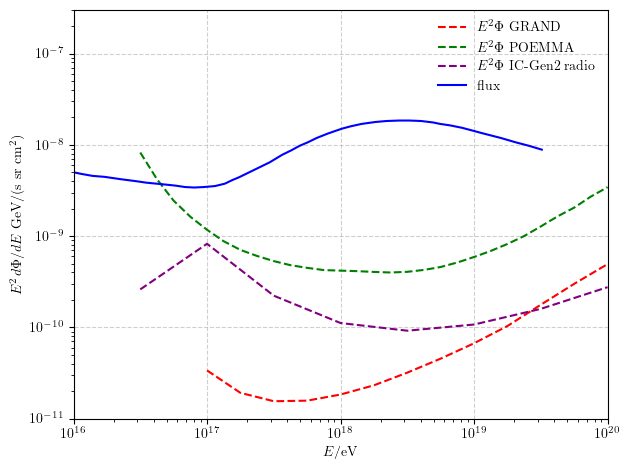

In [81]:
elist_eV = 10**np.linspace(17, 21, 17)# [10.**(9+7+x*1.) for x in range(1,4+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
decade_size = np.log10(elist_eV[1]) - np.log10(elist_eV[0])
print(decade_size)
plt.loglog(elist_eV, 
           decade_size * E2Phi_3flavors(elist_GeV,'grand200k',10*year,3),#/elist_GeV**2,
         label=r'$E^2 \Phi$ GRAND',
         linestyle='--', color='red')

elist_eV = 10**np.linspace(16.5, 20, 29) #elist_eV = [10**(9+7+x*0.5) for x in range(1,8+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
decade_size = np.log10(elist_eV[1]) - np.log10(elist_eV[0])
plt.loglog(elist_eV, 
           decade_size * E2Phi_3flavors(elist_GeV,'poemma', 
                          0.2* 5*year*0.5,1),#/elist_GeV**2, # 0.2 duty cycle=20%
         label=r'$E^2 \Phi$ POEMMA',
         linestyle='--', color='green')


elist_eV = 10**np.linspace(16.5, 20, 29) # elist_eV = [10.**(9+7+x*1.) for x in range(1,4+1,1)]
elist_GeV = (1e-9 * np.array(elist_eV))
decade_size = np.log10(elist_eV[1]) - np.log10(elist_eV[0])
plt.loglog(elist_eV, 
           decade_size * E2Phi_3flavors(elist_GeV,'ICgen2radio',10*year,1),#/elist_GeV**2,  
           # 3 with time for area of 3 species 
           # divide by 3 for only one species (tau)
         label=r'$E^2 \Phi$ IC-Gen2 radio',
         linestyle='--', color='purple')

# plt.plot(10**neuflux["log10Enu"], neuflux["rate"], linestyle='-', color='blue', label='flux')
plt.plot(10**neuflux["log10Enu"], neuflux["rate"], 
         linestyle='-', color='blue', label='flux')

plt.xlabel(r"$E$/eV")
plt.xlim(1e16, 1e20)
plt.ylabel(r"$E^2 \,d\Phi/dE$ GeV/(s sr cm$^2$)")

plt.ylim(1e-11,3e-7)
# plt.title("fig ")
plt.grid(True, ls="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

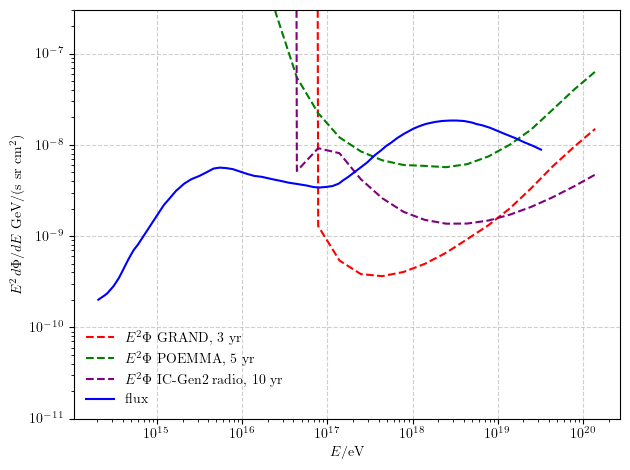

In [43]:
exps = [
    ('grand200k', 3*year, 'red', 0.25, r'$E^2 \Phi$ GRAND, 3 yr'),
    ('poemma', 0.2*5*year*0.5, 'green', 0.25, r'$E^2 \Phi$ POEMMA, 5 yr'),
    ('ICgen2radio', 10*year, 'purple', 0.25, r'$E^2 \Phi$ IC-Gen2 radio, 10 yr')
]

for name, tobs, col, step, lab in exps:
    # Generate bin edges in eV
    edges_eV = 10.**(16 + np.arange(0, (4 if step==1.0 else 4.5), step))
    edges_GeV = 1e-9 * edges_eV
    
    # Calculate upper and lower bounds for the bins
    low_GeV, upp_GeV = edges_GeV[:-1], edges_GeV[1:]
    
    # Plot against the geometric mean of the bin (center in log-space)
    bin_centers = (low_GeV + upp_GeV)/2 * 1e9 # Back to eV for x-axis
#     bin_centers = np.sqrt(low_GeV * upp_GeV) * 1e9 # Back to eV for x-axis
    
    # Use Nnu=3 for Grand, Nnu=1 for others based on your snippet logic
    n_nu = 3 if 'grand' in name else 1
    
    plt.loglog(bin_centers, 
               E2Phi_3flavors_bin(upp_GeV, low_GeV, name, tobs, n_nu),
               label=lab, linestyle='--', color=col)

# Plot reference flux
plt.plot(10**neuflux["log10Enu"], neuflux["rate"], color='blue', label='flux')

plt.xlabel(r"$E$/eV")
plt.ylabel(r"$E^2 \,d\Phi/dE$ GeV/(s sr cm$^2$)")
plt.ylim(1e-11, 3e-7)
plt.grid(True, ls="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

IceCube-Gen2 radio is consistent with fig 15 (https://arxiv.org/pdf/2203.08096) with the kink at 1e17 eV. the trend of effective area (the 2nd derivative switching sign) is copied to the kink in sensitivity. 


* IC 10 y , off by 10, fig 15, 2203.08096
* grand 3 y, GOOD, comparable to  fig 5, 1810.09994 note... the area is avg A Omega, no 4pi
* POEMMA 5 y, GOOD, fig 23 nu_tau to tau, 2011.09869 , the area is avg A Omega, no 4pi

note on effective area:

* IC gen-2 area is for one species or only for tau (bcz all three flavors have the same area)
* POEMMA is for nutau to tau, so only tau
* GRAND is not specified, but can be assumed to be for tau only. 


note on sensitivity: 
* IC+POEMMA should for one species, GRAND is for all species depending on the N_nu=3 factor and how it is later treated

**key factors to be careful with:**  
* POEMMA area is for tau, so divide by 3 such that processed N_nu=1
* asssume GRAND is for tau, just like POEMMA, so divide by 3
* IC area is given for tau. combined area is 3 times that (going to denom.) and N_nu=3 gives 3-neutrino sensitivity.

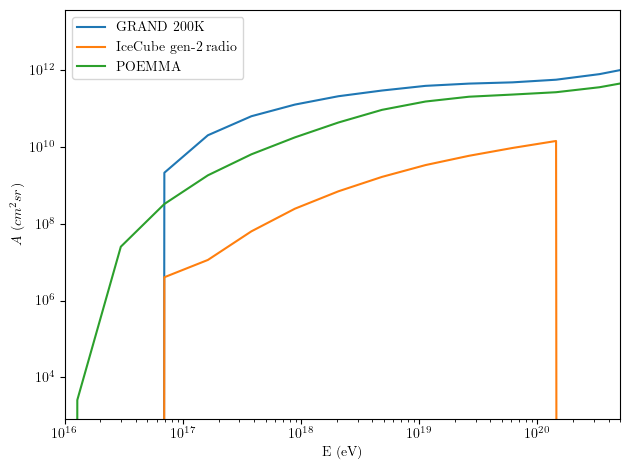

In [377]:
elist = np.logspace(9+6,9+13,20)
plt.plot(elist,grand_area_interp(elist),label='GRAND 200K')
plt.plot(elist,ICgen2radio_area_interp(elist),label='IceCube gen-2 radio')
plt.plot(elist,poemma_area_interp(elist),label='POEMMA')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('E (eV)')
plt.ylabel(r'$A ~(cm^2 sr)$')
plt.xlim(1e16,5e20)
plt.legend()
plt.tight_layout()

In [376]:
ICgen2radio_area_interp(1e18)/(4*np.pi*8e6)

2.9833196195218092

In [457]:
# E_GeV * Tobs * np.log(10) * area_factor
# E^2 2.44 / (E * observation time * log(10) * 4pi * effective area)
(1e9)**2 * 2.44/(1e9 * 10*year*np.log(10) * 4*np.pi * 8e8 ) 

3.342471244528958e-10

## universal tau_count

In [48]:
# Define the integrand_flux_area
def integrand_flux_area_exp(E,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp(E) * area_factor * unit_refiner    # 1/(s)

In [53]:
# Perform the integral
E_min = 1e15        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('poemma',), 
                   limit=500, epsabs=0, epsrel=1e-4)


# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )

poemma tau count: 13.092


In [52]:
# Integration limits in eV
E_min = 1e18        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',), 
                   limit=500, epsabs=0, epsrel=1e-4)

print('POEMMA paper --> grand tau count:', np.round(result * 10*year/3, 3) )

POEMMA paper --> grand tau count: 384.432
